== CEK DATASET DI /kaggle/input ==
[1] "datasets/yooojii/data-analisis-regresi/Data csv pertemuan 1.csv"   
[2] "datasets/yooojii/data-analisis-regresi/Data excel pertemuan 1.xlsx"
[3] "datasets/yooojii/data-analisis-regresi/financials.csv"             
[4] "datasets/yooojii/data-analisis-regresi/idx_listed_companies.csv"   
[5] "datasets/yooojii/data-analisis-regresi/NSC-2025.xlsx"              
[6] "datasets/yooojii/data-analisis-regresi/sp500_esg_data.csv"         
[7] "datasets/yooojii/data-analisis-regresi/sp500_price_data.csv"       

File dipakai:
 /kaggle/input/datasets/yooojii/data-analisis-regresi/financials.csv 

== STRUKTUR DATA ==
'data.frame':	505 obs. of  14 variables:
 $ Symbol        : chr  "MMM" "AOS" "ABT" "ABBV" ...
 $ Name          : chr  "3M Company" "A.O. Smith Corp" "Abbott Laboratories" "AbbVie Inc." ...
 $ Sector        : chr  "Industrials" "Industrials" "Health Care" "Health Care" ...
 $ Price         : num  222.9 60.2 56.3 108.5 150.5 ...
 $ Price.Earnings: 

png 
  2

Plot disimpan: scatter_regresi.png


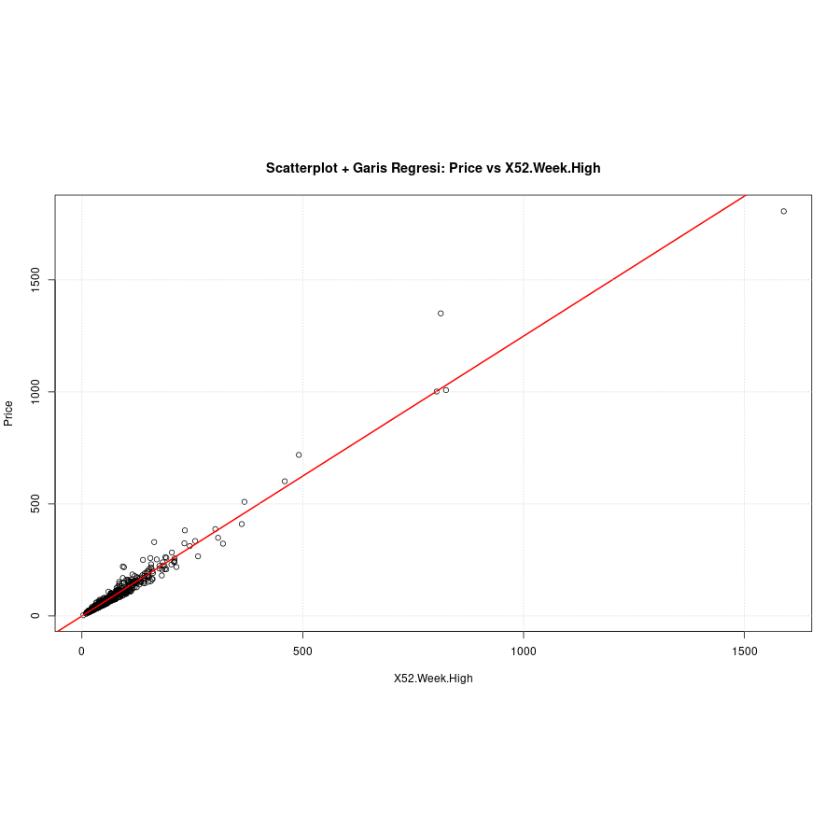

In [6]:
# =========================
# REGRESI LINIER SEDERHANA - financials.csv
# =========================

# 1) cari file financials.csv otomatis
csv_files <- list.files("/kaggle/input", pattern = "financials\\.csv$", recursive = TRUE, full.names = TRUE)
stopifnot(length(csv_files) > 0)
data_path <- csv_files[1]

cat("File dipakai:\n", data_path, "\n\n")

# 2) baca data
dt_raw <- read.csv(data_path, stringsAsFactors = FALSE)
cat("== STRUKTUR DATA ==\n")
print(str(dt_raw))
cat("\n== HEAD DATA ==\n")
print(head(dt_raw))
cat("\n")

# 3) pilih Y dan X
y_col <- "Price"
x_col <- "X52.Week.High"

cat("== VARIABEL ANALISIS ==\n")
cat("Y =", y_col, "\n")
cat("X =", x_col, "\n\n")

# 4) cek kolom ada atau tidak
if (!(y_col %in% names(dt_raw))) stop(paste("Kolom Y tidak ada:", y_col))
if (!(x_col %in% names(dt_raw))) stop(paste("Kolom X tidak ada:", x_col))

# 5) ambil variabel + bersihin
dt <- data.frame(
  y = as.numeric(dt_raw[[y_col]]),
  x = as.numeric(dt_raw[[x_col]])
)
dt <- na.omit(dt)

n <- nrow(dt)
cat("== RINGKAS DATA BERSIH ==\n")
cat("Jumlah observasi (n) =", n, "\n")
cat("Ringkasan Y (Price):\n"); print(summary(dt$y))
cat("Ringkasan X (Earnings.Share):\n"); print(summary(dt$x))
cat("\n")

# =========================
# MODEL
# =========================
model <- lm(y ~ x, data = dt)

cat("== PERSAMAAN REGRESI ==\n")
b0 <- coef(model)[1]
b1 <- coef(model)[2]
cat(sprintf("y_hat = %.6f + %.6f x\n\n", b0, b1))

cat("== RINGKASAN MODEL (summary) ==\n")
print(summary(model))
cat("\n")

# =========================
# ANOVA + KTG + s
# =========================
cat("== ANOVA ==\n")
anova.model <- anova(model)
print(anova.model)
cat("\n")

KTG <- anova.model$`Mean Sq`[2]
s <- sqrt(KTG)

cat("== ESTIMASI RAGAM GALAT ==\n")
cat(sprintf("KTG (MSE) = %.6f\n", KTG))
cat(sprintf("s = sqrt(KTG) = %.6f\n\n", s))

# =========================
# SE(b0), SE(b1), uji-t manual
# =========================
x <- dt$x
xbar <- mean(x)
Sxx <- sum((x - xbar)^2)

se_b1 <- sqrt(KTG / Sxx)
se_b0 <- sqrt(KTG * (1/n + (xbar^2)/Sxx))

t_b1 <- b1 / se_b1
t_b0 <- b0 / se_b0

alpha <- 0.05
t_kritis <- abs(qt(alpha/2, df = n - 2))

cat("== INFERENSI PARAMETER (MANUAL) ==\n")
out_param <- data.frame(
  Parameter = c("beta0 (intersep)", "beta1 (slope)"),
  Estimasi   = c(b0, b1),
  SE         = c(se_b0, se_b1),
  t_hitung   = c(t_b0, t_b1),
  t_kritis   = c(t_kritis, t_kritis)
)
print(out_param)
cat("\n")

# =========================
# CI beta0 & beta1 (95%)
# =========================
CI_b0 <- c(b0 - t_kritis*se_b0, b0 + t_kritis*se_b0)
CI_b1 <- c(b1 - t_kritis*se_b1, b1 + t_kritis*se_b1)

cat("== SELANG KEPERCAYAAN 95% ==\n")
out_ci <- data.frame(
  Parameter = c("beta0", "beta1"),
  Lower_95  = c(CI_b0[1], CI_b1[1]),
  Upper_95  = c(CI_b0[2], CI_b1[2])
)
print(out_ci)
cat("\n")

# =========================
# R^2 manual (biar keliatan kerja)
# =========================
y <- dt$y
yhat <- fitted(model)

JKT <- sum((y - mean(y))^2)
JKS <- sum((y - yhat)^2)
R2  <- 1 - (JKS/JKT)

cat("== UKURAN KEBAIKAN MODEL ==\n")
cat(sprintf("JKT = %.6f\n", JKT))
cat(sprintf("JKS = %.6f\n", JKS))
cat(sprintf("R^2 = 1 - JKS/JKT = %.6f\n\n", R2))

# =========================
# PREDIKSI di x0 + CI rataan & PI individu
# =========================
x0 <- mean(dt$x)
newdata <- data.frame(x = x0)

cat("== PREDIKSI DI x0 ==\n")
cat(sprintf("x0 yang dipakai = mean(x) = %.6f\n\n", x0))

cat("-- CI rataan (confidence interval) --\n")
print(predict(model, newdata = newdata, interval = "confidence"))
cat("\n-- PI individu (prediction interval) --\n")
print(predict(model, newdata = newdata, interval = "prediction"))
cat("\n")

# =========================
# PLOT (lebih rapi + simpan file)
# =========================
cat("== PLOT ==\n")
png("scatter_regresi.png", width = 900, height = 600)
plot(dt$x, dt$y,
     xlab = x_col, ylab = y_col,
     main = paste("Scatterplot + Garis Regresi:", y_col, "vs", x_col))
abline(model, col = "red", lwd = 2)
grid()
dev.off()

cat("Plot disimpan: scatter_regresi.png\n")
# tampilkan plotnya di output notebook
img <- png::readPNG("scatter_regresi.png")
grid::grid.raster(img)


# **Kesimpulan**

Berdasarkan hasil analisis regresi linier sederhana antara Price sebagai peubah respon dan X52.Week.High sebagai peubah penjelas, diperoleh model regresi sebagai berikut:


# ***Price^=−0.5561+1.2496×X52.Week.High***


Hasil pendugaan menunjukkan bahwa koefisien slope bernilai positif dan signifikan secara statistik pada tingkat signifikansi 5% (p-value < 0.05). Hal ini mengindikasikan bahwa terdapat hubungan linier yang sangat kuat antara harga saham saat ini dan harga tertinggi saham dalam 52 minggu terakhir. Secara interpretatif, setiap kenaikan satu satuan harga tertinggi saham dalam 52 minggu terakhir diikuti oleh kenaikan rataan harga saham saat ini sebesar sekitar 1.25 satuan, dengan asumsi faktor lain konstan.

Nilai koefisien determinasi yang dihasilkan sebesar R² = 0.9659, yang berarti sekitar 96.59% variasi harga saham dapat dijelaskan oleh variasi harga tertinggi saham dalam 52 minggu terakhir. Nilai R² yang sangat tinggi ini menunjukkan bahwa model memiliki kemampuan penjelasan yang sangat baik secara numerik.

Namun demikian, tingginya nilai R² perlu diinterpretasikan secara hati-hati. Hubungan antara harga saham saat ini dan harga tertinggi dalam 52 minggu terakhir bersifat deskriptif dan struktural, karena kedua variabel berada dalam domain harga saham yang sama. Dengan kata lain, model ini lebih menggambarkan posisi harga saham saat ini relatif terhadap rentang historisnya, dan bukan menjelaskan faktor-faktor fundamental yang menyebabkan perubahan harga saham.

Dengan demikian, meskipun model regresi yang diperoleh memiliki tingkat kecocokan yang sangat tinggi dan signifikan secara statistik, model ini tidak dimaksudkan untuk menjelaskan hubungan sebab-akibat ekonomi secara mendalam, melainkan untuk menggambarkan keterkaitan linier antara harga saham saat ini dan harga maksimum tahunan yang pernah dicapai.